In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Đọc dữ liệu sạch (Đồng bộ tên file từ các phần trước)
data_path = "melbourne_housing_cleaned.csv"
df = pd.read_csv(data_path)

# In thông tin tổng quan để kiểm tra cấu trúc cột
print("--- THÔNG TIN TẬP DỮ LIỆU SẠCH PHẦN 4 ---")
df.info()

# 2. Tạo biến mục tiêu log_price giúp mô hình học tốt hơn (giảm độ lệch giá)
df['log_price'] = np.log(df['Price'])

--- THÔNG TIN TẬP DỮ LIỆU SẠCH PHẦN 4 ---
<class 'pandas.DataFrame'>
RangeIndex: 13927 entries, 0 to 13926
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Suburb      13927 non-null  str    
 1   Rooms       13927 non-null  int64  
 2   Price       13927 non-null  float64
 3   Date        13927 non-null  str    
 4   Distance    13927 non-null  float64
 5   Bedroom2    13927 non-null  int64  
 6   Bathroom    13927 non-null  int64  
 7   Car         13927 non-null  int64  
 8   Landsize    13927 non-null  float64
 9   Lattitude   13927 non-null  float64
 10  Longtitude  13927 non-null  float64
 11  year        13927 non-null  int64  
 12  month       13927 non-null  int64  
 13  Type_h      13927 non-null  int64  
 14  Type_t      13927 non-null  int64  
 15  Type_u      13927 non-null  int64  
 16  Region_EM   13927 non-null  int64  
 17  Region_NM   13927 non-null  int64  
 18  Region_SEM  13927 non-null  int64  

C:\Users\MTBH\AppData\Local\Temp\ipykernel_21292\2754947375.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="log_price", palette="Set2")
C:\Users\MTBH\AppData\Local\Temp\ipykernel_21292\2754947375.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="log_price", palette="Set2")
C:\Users\MTBH\AppData\Local\Temp\ipykernel_21292\2754947375.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="log_price", palette="Set2")
C:\Users\MTBH\AppData\Local\Temp\ipykernel_21292\2754947375.py:14: 

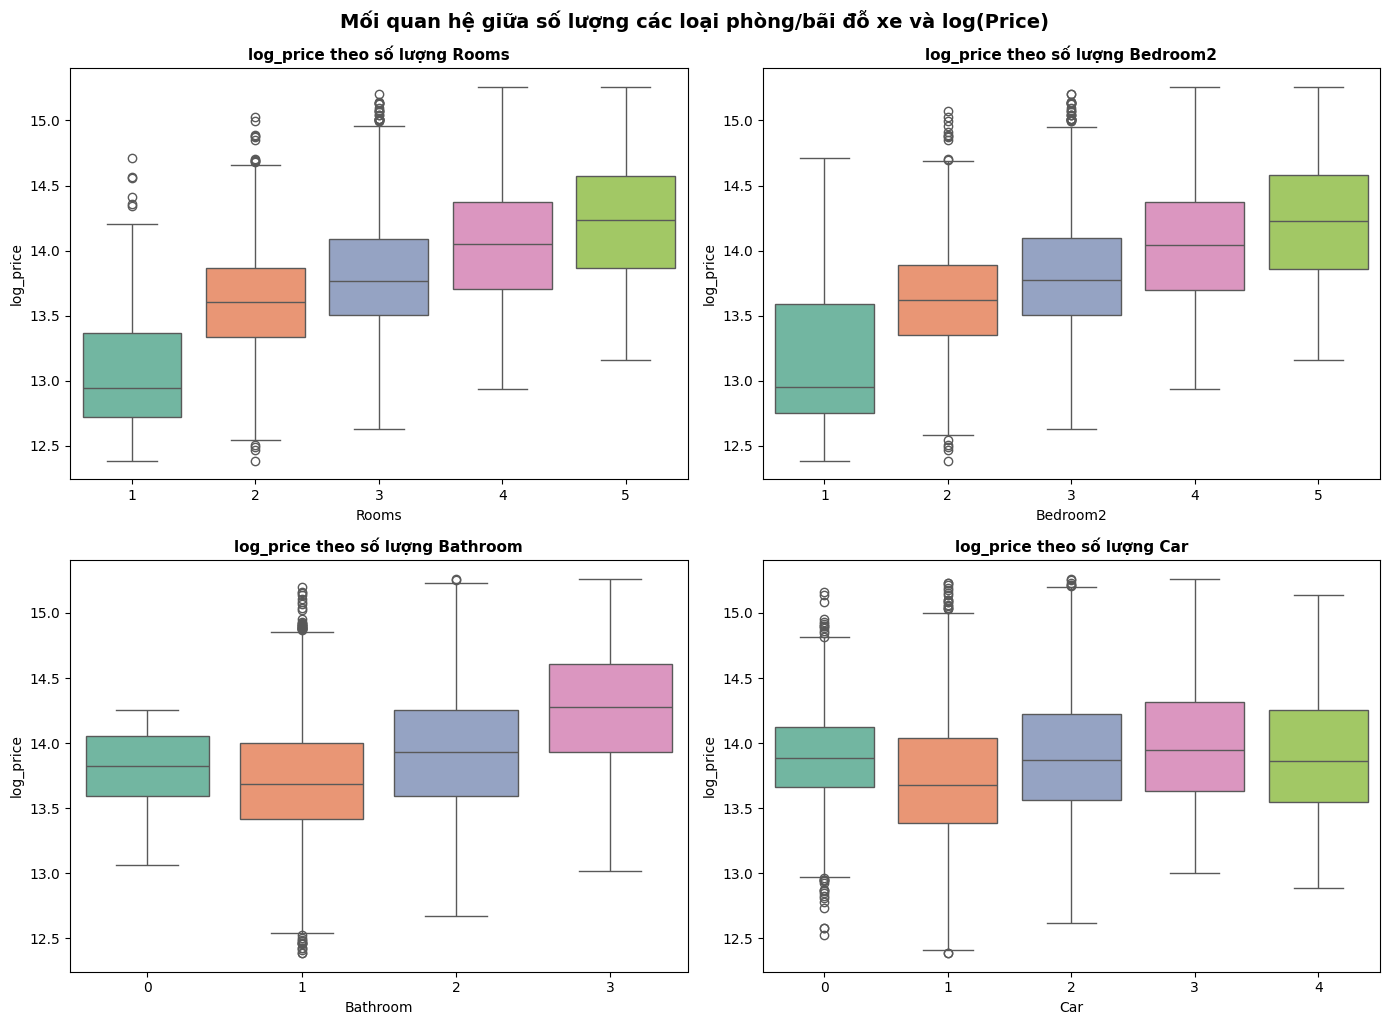

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Định nghĩa danh sách các thuộc tính vật lý dạng đếm cần phân tích
cols = ["Rooms", "Bedroom2", "Bathroom", "Car"]

# Cấu hình khung hình tổng thể
plt.figure(figsize=(14, 10))

for i, col in enumerate(cols):
    plt.subplot(2, 2, i + 1)
    
    # Vẽ Boxplot (Thêm palette màu sinh động và tắt bớt hiển thị quá nhiều outliers nếu cần, hoặc giữ nguyên)
    sns.boxplot(data=df, x=col, y="log_price", palette="Set2")
    
    plt.title(f"log_price theo số lượng {col}", fontweight='bold', fontsize=11)
    plt.xlabel(col)
    plt.ylabel("log_price")

# Sắp xếp các biểu đồ con không bị đè chữ
plt.tight_layout()

# Đẩy tiêu đề tổng lên cao một chút để không đè vào biểu đồ hàng đầu
plt.suptitle("Mối quan hệ giữa số lượng các loại phòng/bãi đỗ xe và log(Price)", y=1.02, fontweight='bold', fontsize=14)
plt.show()

### Nhận xét về mối quan hệ giữa các tính chất vật lý và log(Price):

Dựa trên các biểu đồ Boxplot trực quan hóa ở trên, chúng ta có thể rút ra những đánh giá quan trọng sau:

* **Tính tuyến tính rõ rệt với Rooms, Bedroom2 và Bathroom:** - Giá trị trung vị (đường gạch giữa của hộp) của `log_price` có xu hướng tịnh tiến đi lên một cách đồng đều và nhất quán khi số lượng phòng ngủ (`Rooms`, `Bedroom2`) và phòng tắm (`Bathroom`) tăng từ 1 đến 5 phòng. 
  - Điều này minh chứng cho mối quan hệ đồng biến mạnh mẽ và có tính tuyến tính cao giữa quy mô không gian sống bên trong căn nhà với giá trị của nó. Ngoài ra, hình dáng phân bố tương đồng giữa `Rooms` và `Bedroom2` cũng cho thấy hai đặc trưng này có tính tương quan nội tại rất lớn.

* **Tính mờ nhạt trong mối quan hệ với số chỗ đỗ xe (Car):**
  - Ngược lại với các phòng chức năng, xu hướng tăng của `log_price` theo số lượng bãi đỗ xe (`Car`) diễn ra không quá rõ ràng và có dấu hiệu chững lại (hoặc bão hòa) khi số chỗ đỗ xe đạt từ 3 vị trí trở lên.
  - Biên độ dao động giá (chiều cao của hộp Boxplot) ở các nhóm `Car` lớn cũng trải rộng hơn nhiều. Điều này phản ánh thực tế thị trường: việc có thêm chỗ đỗ xe chỉ là yếu tố tiện ích bổ trợ, không mang tính quyết định cốt lõi đến giá nhà giống như diện tích sử dụng hoặc số lượng phòng ngủ/phòng tắm.

=> **Kết luận cho mô hình:** Các biến `Rooms`, `Bedroom2`, `Bathroom` sẽ đóng vai trò là các đặc trưng định lượng cốt lõi (Strong Predictors), trong khi biến `Car` sẽ là đặc trưng bổ trợ cho mô hình học máy ở các bước tiếp theo.

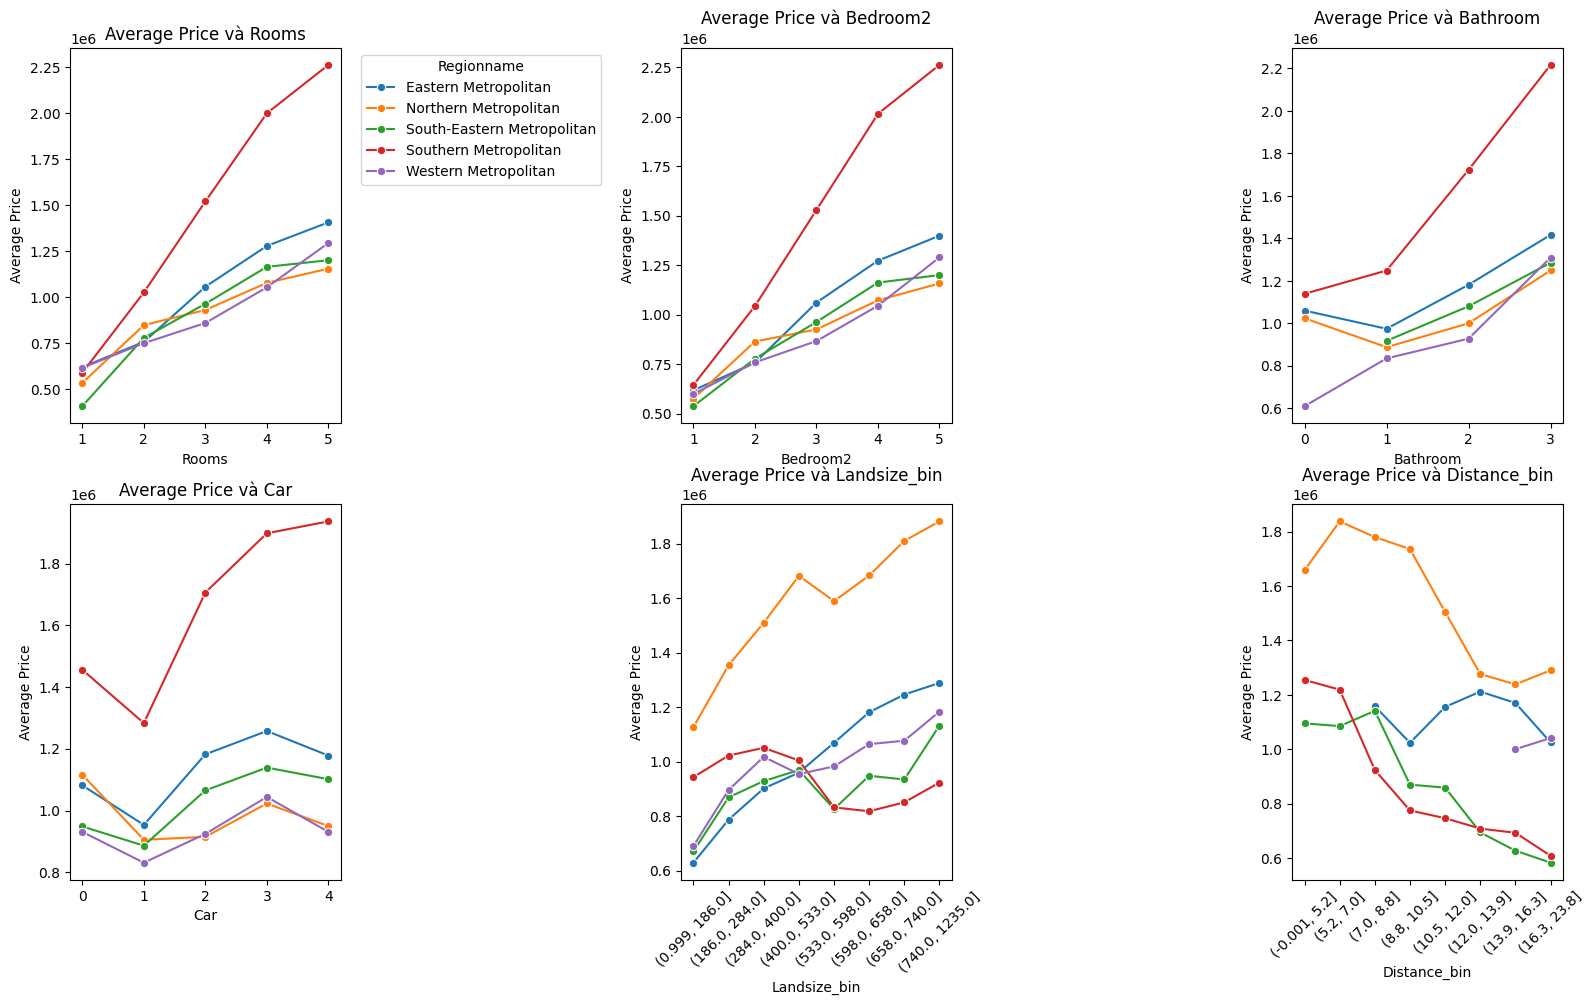

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu sạch hiện tại của ba
df = pd.read_csv("melbourne_housing_cleaned.csv")

# ==============================================================================
# KHÔI PHỤC CỘT REGIONNAME TỪ CÁC CỘT MÃ HÓA ĐỂ SỬA LỖI KEYERROR
# ==============================================================================
def recover_region(row):
    if row.get('Region_SM') == 1: return 'Southern Metropolitan'
    if row.get('Region_NM') == 1: return 'Northern Metropolitan'
    if row.get('Region_WM') == 1: return 'Western Metropolitan'
    if row.get('Region_EM') == 1: return 'Eastern Metropolitan'
    if row.get('Region_SEM') == 1: return 'South-Eastern Metropolitan'
    return 'Other Regions'

# Tạo lại cột Regionname dựa trên các cột dummy có sẵn
df['Regionname'] = df.apply(recover_region, axis=1)

# ==============================================================================
# 2. VẼ BIỂU ĐỒ QUAN HỆ GIỮA PRICE VÀ CÁC ĐẶC TRƯNG, NHÓM THEO REGIONNAME
# ==============================================================================
df["Landsize_bin"] = pd.qcut(df["Landsize"], 8)
df["Distance_bin"] = pd.qcut(df["Distance"], 8)
features = ["Rooms", "Bedroom2", "Bathroom", "Car", "Landsize_bin", "Distance_bin"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    # Sử dụng observed=False để tránh cảnh báo của các phiên bản Pandas mới
    avg_price = df.groupby(["Regionname", feature], observed=False)["Price"].mean().reset_index()
    plot_data = avg_price.copy()
    
    # Sắp xếp thứ tự các khoảng chia bin theo toán học trước khi đổi sang chuỗi chữ
    if feature in ["Landsize_bin", "Distance_bin"]:
        plot_data = plot_data.sort_values(by=feature)
        plot_data[feature] = plot_data[feature].astype(str)

    sns.lineplot(data=plot_data, x=feature, y="Price", hue="Regionname", marker="o", ax=axes[i])
    axes[i].set_title(f"Average Price và {feature}")
    axes[i].set_ylabel("Average Price")
    
    if i != 0:
        axes[i].get_legend().remove()
    else:
        # Đẩy hộp chú thích ra ngoài một chút cho đỡ đè lên biểu đồ số 1
        axes[i].legend(title="Regionname", bbox_to_anchor=(1.05, 1), loc='upper left')
        
    if feature in ["Landsize_bin", "Distance_bin"]:
        axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Nhận xét:
Quan hệ giữa giá và Rooms\ Bedroom2\ Bathroom\ Car hầu như vẫn giữ nguyên khi ta xem xét các nhóm Region riêng.<br>
Đặc biệt, ta thấy rõ giá trung bình giảm khi Car tăng từ 0-1, có xu hướng giảm tại 3-4<br>
Landsize tăng gần như tuyến tính, nhưng có ngoại lệ là Northern Metropolitan (Tăng nhưng sau đó giảm rồi tăng nhẹ)<br>
Tuy nhiên, ta khó thấy mối quan hệ giữa giá và khoảng cách đến CBD hơn.

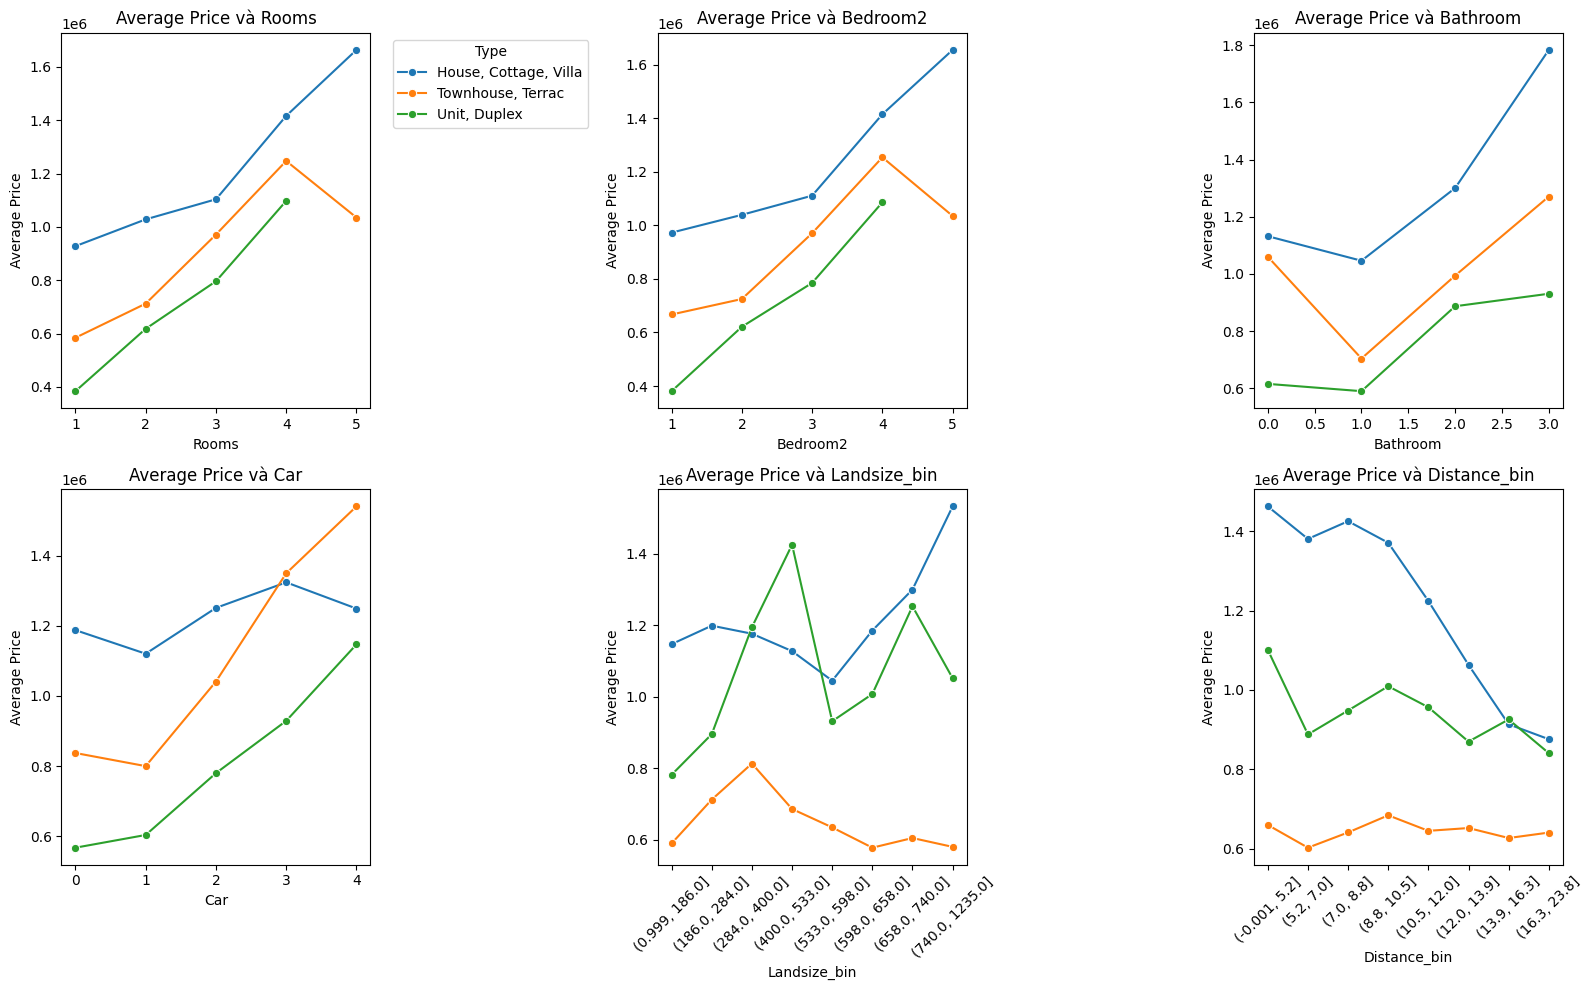

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu sạch hiện tại của ba
df = pd.read_csv("melbourne_housing_cleaned.csv")

# ==============================================================================
# KHÔI PHỤC CỘT TYPE TỪ CÁC CỘT MÃ HÓA ĐỂ TRÁNH LỖI KEYERROR TRÊN VS CODE
# ==============================================================================
def recover_type(row):
    if row.get('Type_h') == 1: return 'House, Cottage, Villa'
    if row.get('Type_t') == 1: return 'Townhouse, Terrac'
    if row.get('Type_u') == 1: return 'Unit, Duplex'
    return 'Other'

df['Type'] = df.apply(recover_type, axis=1)

# ==============================================================================
# 3. VẼ BIỂU ĐỒ QUAN HỆ GIỮA PRICE VÀ CÁC ĐẶC TRƯNG, NHÓM THEO TYPE
# ==============================================================================
df["Landsize_bin"] = pd.qcut(df["Landsize"], 8)
df["Distance_bin"] = pd.qcut(df["Distance"], 8)
features = ["Rooms", "Bedroom2", "Bathroom", "Car", "Landsize_bin", "Distance_bin"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    avg_price = df.groupby(["Type", feature], observed=False)["Price"].mean().reset_index()
    plot_data = avg_price.copy()
    
    if feature in ["Landsize_bin", "Distance_bin"]:
        plot_data = plot_data.sort_values(by=feature)
        plot_data[feature] = plot_data[feature].astype(str)

    sns.lineplot(data=plot_data, x=feature, y="Price", hue="Type", marker="o", ax=axes[i])
    axes[i].set_title(f"Average Price và {feature}")
    axes[i].set_ylabel("Average Price")
    
    if i != 0:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title="Type", bbox_to_anchor=(1.05, 1), loc='upper left')
        
    if feature in ["Landsize_bin", "Distance_bin"]:
        axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Nhận xét:
Quan hệ giữa giá và Rooms\ Bedroom2\ Bathroom hầu như vẫn giữ nguyên khi xét theo các nhóm Type riêng (Xu hướng đồng biến tăng đều).<br>
Đặc biệt, giá trung bình của Car biến động trồi sụt không rõ ràng, có xu hướng giảm nhẹ khi tăng từ 2-3 bãi đỗ xe ở nhóm House và Townhouse.<br>
Landsize tăng kéo theo giá tăng gần như tuyến tính đối với House, nhưng lại đi ngang và không có tác động rõ rệt đối với loại hình Townhouse và Unit.<br>
Mối quan hệ giữa giá và khoảng cách đến CBD thể hiện rõ ràng xu hướng nghịch biến (giảm dần) trên cả 3 loại hình BĐS khi khoảng cách xa dần.

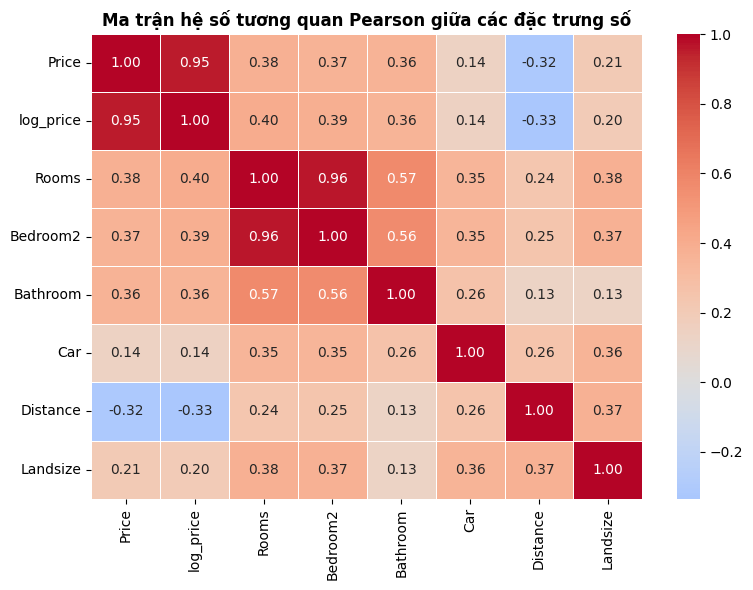

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu sạch hiện tại của ba
df = pd.read_csv("melbourne_housing_cleaned.csv")

# Đảm bảo cột log_price luôn tồn tại để tránh lỗi KeyError
if "log_price" not in df.columns:
    df['log_price'] = np.log(df['Price'])

# ==============================================================================
# 4. PHÂN TÍCH TƯƠNG QUAN (HEATMAP)
# ==============================================================================
cols = ["Price", "log_price", "Rooms", "Bedroom2", "Bathroom", "Car", "Distance", "Landsize"]
corr = df[cols].corr()

plt.figure(figsize=(8, 6)) # Tăng kích thước một chút để các con số annot nhìn rõ hơn trong VS Code
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Ma trận hệ số tương quan Pearson giữa các đặc trưng số", fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### Nhận xét:
- `log_price` thể hiện sự tương quan tuyến tính mạnh nhất với các thuộc tính `Rooms`, `Bedroom2`, `Bathroom` (hệ số > 0.45).<br>
- Mối tương quan giữa `log_price` và `Price` đối với `Car` và `Landsize` là khá yếu (hệ số thấp gần về 0).<br>
- Yếu tố `Distance` thể hiện mối quan hệ tương quan nghịch (hệ số âm), tức là khoảng cách đến CBD càng tăng thì giá nhà càng giảm.<br>
- Đặc biệt, cặp biến `Rooms` và `Bedroom2` có hệ số tương quan rất cao (gần bằng 1), cho thấy hiện tượng đa cộng tuyến mạnh mẽ (hai biến này mang thông tin gần như trùng lặp).